In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


In [2]:

df = pd.read_csv("letter-recognition.csv")
print(df.head())

x = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)

scaler = StandardScaler()
x = scaler.fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)



  letter  xbox   ybox   width   height  onpix   xbar   ybar   x2bar  y2bar   \
0      T      2      8       3       5       1      8     13      0       6   
1      I      5     12       3       7       2     10      5      5       4   
2      D      4     11       6       8       6     10      6      2       6   
3      N      7     11       6       6       3      5      9      4       6   
4      G      2      1       3       1       1      8      6      6       6   

   xybar   x2ybar  xy2bar  xedge   xedgey  yedge   yedgex  
0       6      10       8       0       8       0       8  
1      13       3       9       2       8       4      10  
2      10       3       7       3       7       3       9  
3       4       4      10       6      10       2       8  
4       6       5       9       1       7       5      10  


In [3]:
model = Sequential([
    Input(shape=(16,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(26, activation='softmax')
])



In [4]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [5]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)



Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5837 - loss: 1.5793 - val_accuracy: 0.7434 - val_loss: 0.9066
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7947 - loss: 0.7299 - val_accuracy: 0.8075 - val_loss: 0.6626
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8376 - loss: 0.5559 - val_accuracy: 0.8566 - val_loss: 0.5252
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8683 - loss: 0.4545 - val_accuracy: 0.8647 - val_loss: 0.4505
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8888 - loss: 0.3838 - val_accuracy: 0.8784 - val_loss: 0.4028
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9042 - loss: 0.3312 - val_accuracy: 0.8950 - val_loss: 0.3485
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9162 - loss: 0.2893 - val_accuracy: 0.9009 - val_loss: 0.3257
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9234 - loss: 0.2616 - val_accuracy: 0.

In [6]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)



125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9525 - loss: 0.1526
Test Accuracy: 0.9524999856948853


In [7]:
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)
pred_letters = le.inverse_transform(pred_classes)

print(pred_letters[:10])



125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
['T' 'L' 'A' 'E' 'Q' 'E' 'O' 'Q' 'G' 'O']


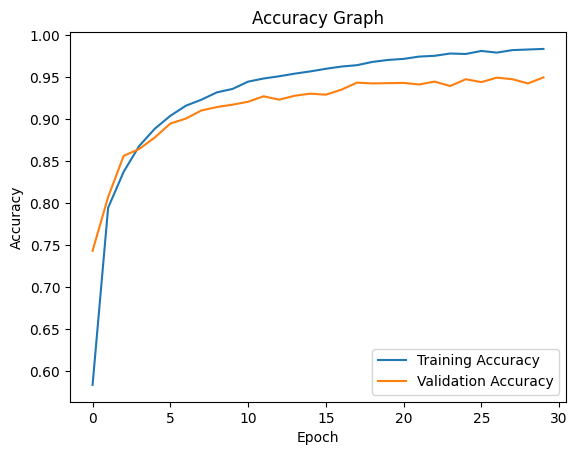

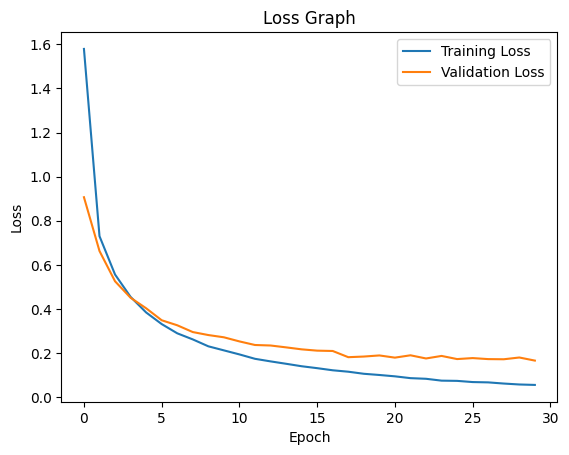

In [8]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()